# AI Lead Quality Prediction

This project builds a multi-class classification system that predicts whether a business lead is Low, Medium, or High quality from company, contact, engagement, and business-size features.

In [56]:
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder

try:
    from xgboost import XGBClassifier
except ImportError as exc:
    raise ImportError(
        "Install xgboost before running this notebook: "
        "pip install xgboost"
    ) from exc

sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42
CLASS_LABELS = ["Low", "Medium", "High"]

## Dataset Loading

Load the provided CSV and inspect its structure before making any changes.

In [57]:
DATA_PATH = "lead_quality_dataset.csv"
df = pd.read_csv(DATA_PATH)

print("First 5 rows:")
display(df.head())
print("Dataset shape:", df.shape)
print("Column names:", df.columns.tolist())
print("Data types:")
display(df.dtypes.to_frame("dtype"))

First 5 rows:


,Industry,Company_Size,Website_Quality,LinkedIn_Activity,Email_Available,Location,Estimated_Revenue,Number_of_Employees,Previous_Response,Meeting_Status,Lead_Quality
0,Education,Medium,Good,Low,Yes,Rawalpindi,17412000.0,28,Negative,Not Contacted,Low
1,Real Estate,Medium,Excellent,Medium,Yes,Quetta,457000.0,116,Neutral,Scheduled,Low
2,Finance,Small,Good,High,Yes,Islamabad,1450000.0,397,Neutral,Scheduled,High
3,Retail,Large,Poor,Medium,No,Karachi,14542000.0,62,Neutral,Completed,Medium
4,Real Estate,Large,Good,Low,Yes,Karachi,1114000.0,33,No Response,Not Scheduled,Medium


Dataset shape: (5025, 11)
Column names: ['Industry', 'Company_Size', 'Website_Quality', 'LinkedIn_Activity', 'Email_Available', 'Location', 'Estimated_Revenue', 'Number_of_Employees', 'Previous_Response', 'Meeting_Status', 'Lead_Quality']
Data types:


,dtype
Industry,str
Company_Size,str
Website_Quality,str
LinkedIn_Activity,str
Email_Available,str
Location,str
Estimated_Revenue,float64
Number_of_Employees,int64
Previous_Response,str
Meeting_Status,str


## Data Quality Inspection

Inspect missing values, duplicates, categorical levels, target balance, and descriptive statistics before cleaning.

In [58]:
categorical_columns = [
    "Industry", "Company_Size", "Website_Quality", "LinkedIn_Activity",
    "Email_Available", "Location", "Previous_Response", "Meeting_Status"
]

print("Missing values:")
display(df.isna().sum().rename("missing_values").to_frame())
print("Duplicate rows:", int(df.duplicated().sum()))
print("\nUnique categorical values:")
for column in categorical_columns:
    print(f"{column}: {sorted(df[column].dropna().unique().tolist())}")
print("\nTarget class distribution:")
display(df["Lead_Quality"].value_counts(dropna=False).rename("count").to_frame())
print("\nDescriptive statistics:")
display(df.describe(include="all").T)

Missing values:


,missing_values
Industry,0
Company_Size,0
Website_Quality,100
LinkedIn_Activity,100
Email_Available,0
Location,0
Estimated_Revenue,100
Number_of_Employees,0
Previous_Response,100
Meeting_Status,0


Duplicate rows: 25

Unique categorical values:
Industry: ['Education', 'Finance', 'Healthcare', 'Manufacturing', 'Marketing', 'Real Estate', 'Retail', 'Technology']
Company_Size: ['Large', 'Medium', 'Small']
Website_Quality: ['Average', 'Excellent', 'Good', 'Poor']
LinkedIn_Activity: ['High', 'Low', 'Medium']
Email_Available: ['No', 'Yes']
Location: ['Faisalabad', 'Islamabad', 'Karachi', 'Lahore', 'Multan', 'Peshawar', 'Quetta', 'Rawalpindi']
Previous_Response: ['Negative', 'Neutral', 'No Response', 'Positive']
Meeting_Status: ['Completed', 'Not Contacted', 'Not Scheduled', 'Scheduled']

Target class distribution:


,count
Lead_Quality,
Medium,1761
Low,1758
High,1506



Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Industry,5025,8,Technology,1037,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Company_Size,5025,3,Small,2316,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Website_Quality,4925,4,Good,1837,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LinkedIn_Activity,4925,3,Medium,2269,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Email_Available,5025,2,Yes,4086,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,5025,8,Faisalabad,663,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Estimated_Revenue,4925.0,NaN,NaN,NaN,2395985.989848,2879247.198936,39000.0,760000.0,1503000.0,2875000.0,37369000.0
Number_of_Employees,5025.0,NaN,NaN,NaN,148.210547,166.087017,5.0,53.0,98.0,185.0,2772.0
Previous_Response,4925,4,Positive,1697,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Meeting_Status,5025,4,Scheduled,1530,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data Cleaning

The dataset intentionally contains missing values and duplicate rows. Duplicates are removed, while missing feature values are retained for pipeline imputation.

In [59]:
rows_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape before duplicate removal: ({rows_before}, {df.shape[1]})")
print(f"Shape after duplicate removal: {df.shape}")
print("Missing values after duplicate removal:")
display(df.isna().sum().rename("missing_values").to_frame())

Shape before duplicate removal: (5025, 11)
Shape after duplicate removal: (5000, 11)
Missing values after duplicate removal:


,missing_values
Industry,0
Company_Size,0
Website_Quality,100
LinkedIn_Activity,100
Email_Available,0
Location,0
Estimated_Revenue,100
Number_of_Employees,0
Previous_Response,100
Meeting_Status,0


## Exploratory Data Analysis (EDA)

Visualize the target distribution to understand class balance.

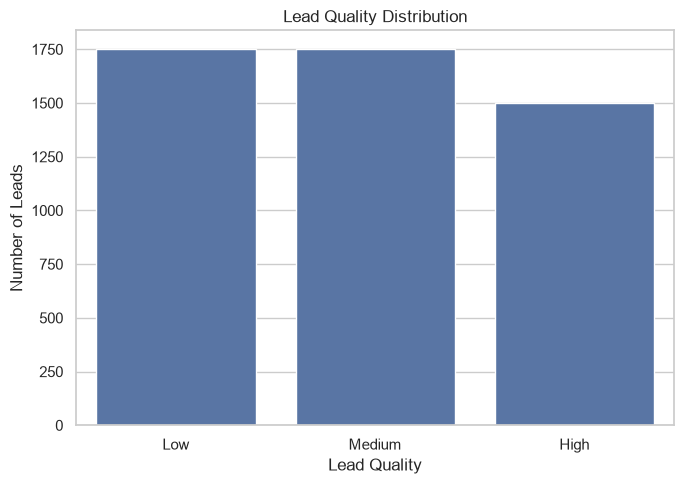

In [60]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Lead_Quality", order=CLASS_LABELS)
plt.title("Lead Quality Distribution")
plt.xlabel("Lead Quality")
plt.ylabel("Number of Leads")
plt.tight_layout()
plt.show()

## Industry vs Lead Quality

Compare lead-quality classes across industries.

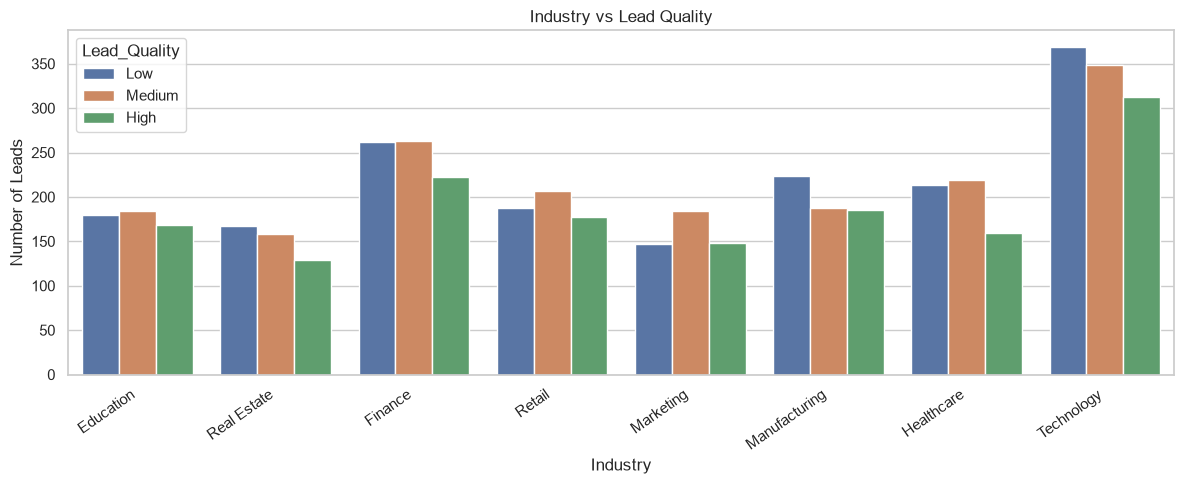

In [61]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x="Industry", hue="Lead_Quality", hue_order=CLASS_LABELS)
plt.title("Industry vs Lead Quality")
plt.xlabel("Industry")
plt.ylabel("Number of Leads")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

## Company Size vs Lead Quality

Compare lead-quality classes across company-size categories.

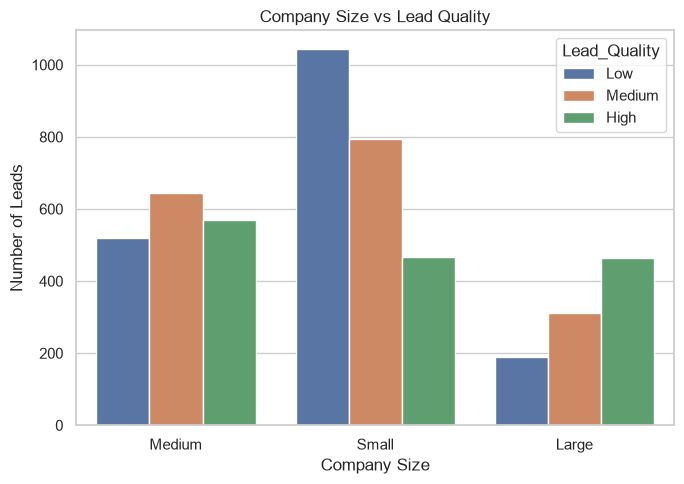

In [62]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Company_Size", hue="Lead_Quality", hue_order=CLASS_LABELS)
plt.title("Company Size vs Lead Quality")
plt.xlabel("Company Size")
plt.ylabel("Number of Leads")
plt.tight_layout()
plt.show()

## Website Quality vs Lead Quality

Compare the target across website-quality levels.

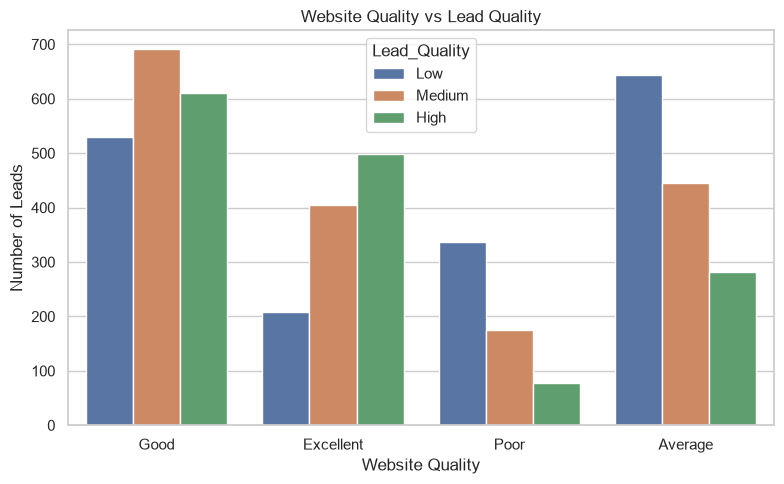

In [63]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Website_Quality", hue="Lead_Quality", hue_order=CLASS_LABELS)
plt.title("Website Quality vs Lead Quality")
plt.xlabel("Website Quality")
plt.ylabel("Number of Leads")
plt.tight_layout()
plt.show()

## LinkedIn Activity vs Lead Quality

Compare lead quality across LinkedIn activity levels.

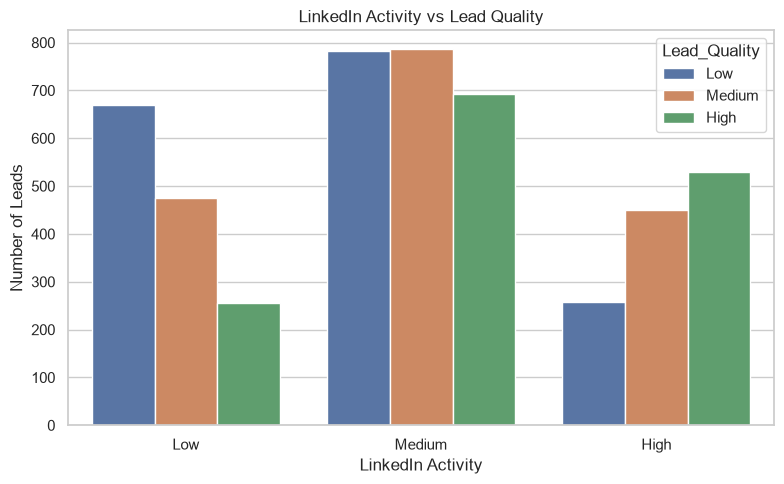

In [64]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="LinkedIn_Activity", hue="Lead_Quality", hue_order=CLASS_LABELS)
plt.title("LinkedIn Activity vs Lead Quality")
plt.xlabel("LinkedIn Activity")
plt.ylabel("Number of Leads")
plt.tight_layout()
plt.show()

## Email Availability vs Lead Quality

Compare the target distribution for leads with and without an available email.

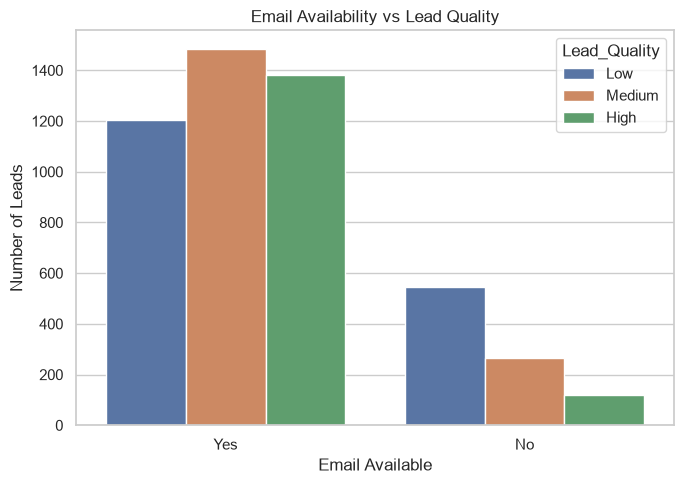

In [65]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Email_Available", hue="Lead_Quality", hue_order=CLASS_LABELS)
plt.title("Email Availability vs Lead Quality")
plt.xlabel("Email Available")
plt.ylabel("Number of Leads")
plt.tight_layout()
plt.show()

## Location vs Lead Quality

Compare lead-quality classes across locations.

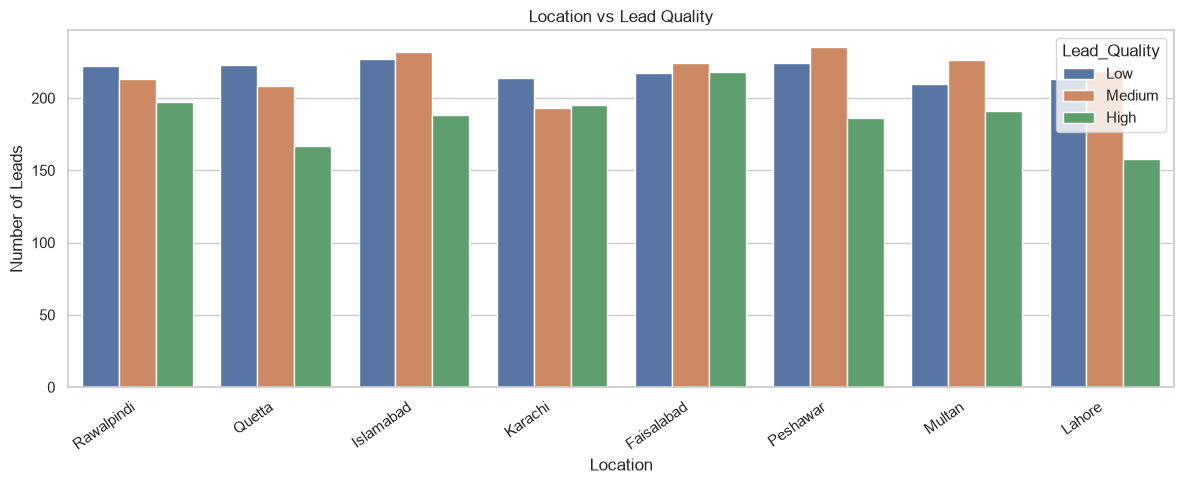

In [66]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x="Location", hue="Lead_Quality", hue_order=CLASS_LABELS)
plt.title("Location vs Lead Quality")
plt.xlabel("Location")
plt.ylabel("Number of Leads")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

## Previous Response vs Lead Quality

Compare lead quality across previous-response categories.

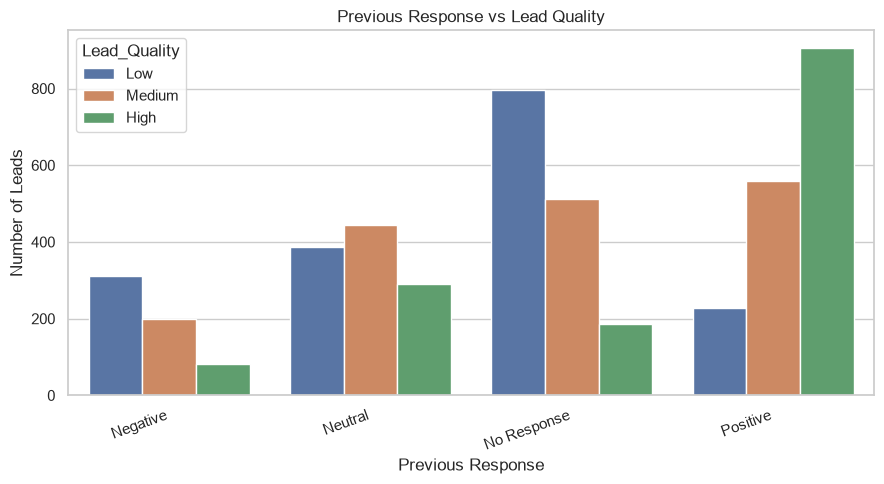

In [67]:
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x="Previous_Response", hue="Lead_Quality", hue_order=CLASS_LABELS)
plt.title("Previous Response vs Lead Quality")
plt.xlabel("Previous Response")
plt.ylabel("Number of Leads")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## Meeting Status vs Lead Quality

Compare lead quality across meeting-status categories.

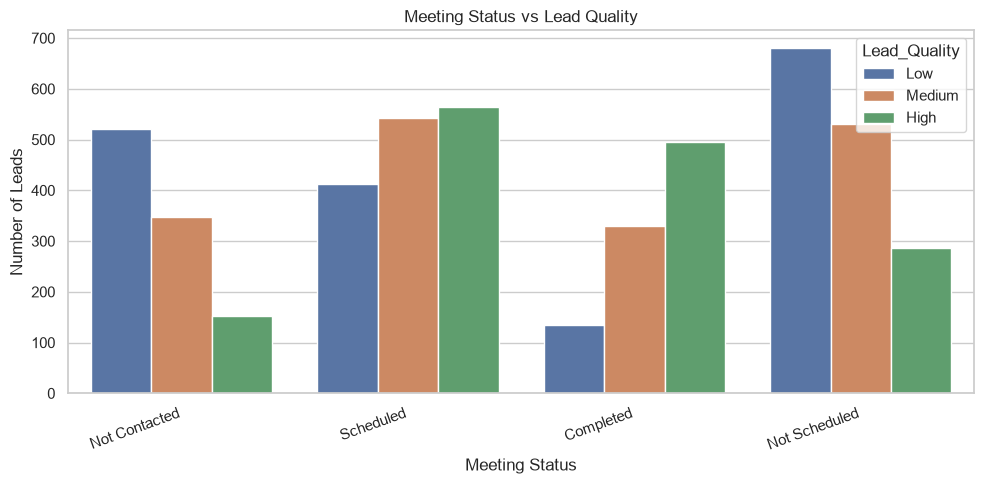

In [68]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="Meeting_Status", hue="Lead_Quality", hue_order=CLASS_LABELS)
plt.title("Meeting Status vs Lead Quality")
plt.xlabel("Meeting Status")
plt.ylabel("Number of Leads")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## Numerical Feature Analysis

Inspect distributions and potential outliers for revenue and employee count.

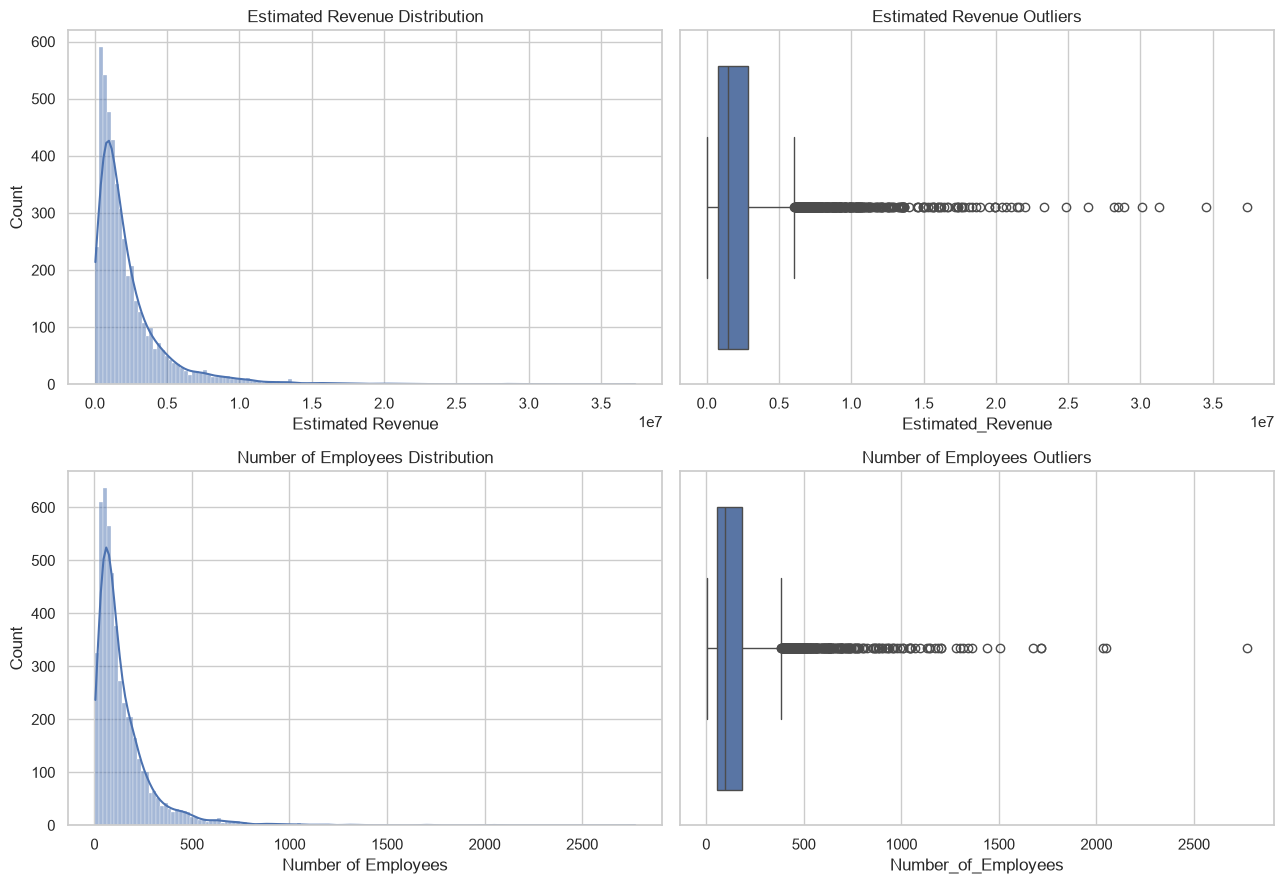

In [69]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
sns.histplot(data=df, x="Estimated_Revenue", kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Estimated Revenue Distribution")
axes[0, 0].set_xlabel("Estimated Revenue")
sns.boxplot(data=df, x="Estimated_Revenue", ax=axes[0, 1])
axes[0, 1].set_title("Estimated Revenue Outliers")
sns.histplot(data=df, x="Number_of_Employees", kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Number of Employees Distribution")
axes[1, 0].set_xlabel("Number of Employees")
sns.boxplot(data=df, x="Number_of_Employees", ax=axes[1, 1])
axes[1, 1].set_title("Number of Employees Outliers")
plt.tight_layout()
plt.show()

## EDA Pattern Analysis

Calculate actual within-group lead-quality percentages to support observations without hard-coded claims.

In [70]:
pattern_columns = [
    "Website_Quality", "LinkedIn_Activity", "Previous_Response",
    "Meeting_Status", "Company_Size"
]
pattern_tables = {}
for column in pattern_columns:
    table = pd.crosstab(df[column], df["Lead_Quality"], normalize="index").reindex(columns=CLASS_LABELS, fill_value=0).mul(100).round(2)
    pattern_tables[column] = table
    print(f"Lead quality percentage by {column}:")
    display(table)

print("Mean numerical features by lead quality:")
display(df.groupby("Lead_Quality")[["Estimated_Revenue", "Number_of_Employees"]].mean().reindex(CLASS_LABELS))

Lead quality percentage by Website_Quality:


Lead_Quality,Low,Medium,High
Website_Quality,,,
Average,46.93,32.48,20.58
Excellent,18.72,36.36,44.91
Good,28.91,37.76,33.33
Poor,57.22,29.71,13.07


Lead quality percentage by LinkedIn_Activity:


Lead_Quality,Low,Medium,High
LinkedIn_Activity,,,
High,20.84,36.35,42.81
Low,47.82,33.98,18.20
Medium,34.63,34.76,30.61


Lead quality percentage by Previous_Response:


...

Lead_Quality,Low,Medium,High
Meeting_Status,,,
Completed,14.05,34.34,51.61
Not Contacted,51.03,33.99,14.99
Not Scheduled,45.46,35.38,19.16
Scheduled,27.17,35.72,37.11


Lead quality percentage by Company_Size:


Lead_Quality,Low,Medium,High
Company_Size,,,
Large,19.52,32.40,48.08
Medium,29.97,37.18,32.85
Small,45.25,34.45,20.30


Mean numerical features by lead quality:


,Estimated_Revenue,Number_of_Employees
Lead_Quality,,
Low,2.277338e+06,136.396571
Medium,2.397679e+06,149.537714
High,2.540389e+06,160.608000


## Key Patterns Observed

The following observations are generated from the calculated EDA tables and describe only the strongest observed class percentages.

In [71]:
for column, table in pattern_tables.items():
    strongest_class = table.idxmax(axis=1)
    strongest_share = table.max(axis=1)
    print(f"{column}: highest observed class by category -> {strongest_class.to_dict()}")
    print(f"{column}: corresponding percentages -> {strongest_share.round(1).to_dict()}")

mean_features = df.groupby("Lead_Quality")[["Estimated_Revenue", "Number_of_Employees"]].mean().reindex(CLASS_LABELS)
print("Mean revenue and employee values by class:")
display(mean_features.round(2))

Website_Quality: highest observed class by category -> {'Average': 'Low', 'Excellent': 'High', 'Good': 'Medium', 'Poor': 'Low'}
Website_Quality: corresponding percentages -> {'Average': 46.9, 'Excellent': 44.9, 'Good': 37.8, 'Poor': 57.2}
LinkedIn_Activity: highest observed class by category -> {'High': 'High', 'Low': 'Low', 'Medium': 'Medium'}
LinkedIn_Activity: corresponding percentages -> {'High': 42.8, 'Low': 47.8, 'Medium': 34.8}
Previous_Response: highest observed class by category -> {'Negative': 'Low', 'Neutral': 'Medium', 'No Response': 'Low', 'Positive': 'High'}
Previous_Response: corresponding percentages -> {'Negative': 52.4, 'Neutral': 39.6, 'No Response': 53.2, 'Positive': 53.5}
Meeting_Status: highest observed class by category -> {'Completed': 'High', 'Not Contacted': 'Low', 'Not Scheduled': 'Low', 'Scheduled': 'High'}
Meeting_Status: corresponding percentages -> {'Completed': 51.6, 'Not Contacted': 51.0, 'Not Scheduled': 45.5, 'Scheduled': 37.1}
Company_Size: highest o

,Estimated_Revenue,Number_of_Employees
Lead_Quality,,
Low,2277337.98,136.40
Medium,2397678.90,149.54
High,2540389.19,160.61


## Feature and Target Definition

Use all ten input columns to predict `Lead_Quality`, which is the three-class target.

In [72]:
feature_columns = [
    "Industry", "Company_Size", "Website_Quality", "LinkedIn_Activity",
    "Email_Available", "Location", "Estimated_Revenue", "Number_of_Employees",
    "Previous_Response", "Meeting_Status"
]
numerical_features = ["Estimated_Revenue", "Number_of_Employees"]
categorical_features = [column for column in feature_columns if column not in numerical_features]

X = df[feature_columns].copy()
y = df["Lead_Quality"].copy()
print("X shape:", X.shape)
print("y distribution:")
display(y.value_counts().reindex(CLASS_LABELS, fill_value=0).rename("count").to_frame())

X shape: (5000, 10)
y distribution:


,count
Lead_Quality,
Low,1750
Medium,1750
High,1500


## Train-Test Split

Use an 80/20 stratified split so class proportions remain comparable in training and testing.

In [73]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print("Training shape:", X_train.shape, y_train.shape)
print("Testing shape:", X_test.shape, y_test.shape)

Training shape: (4000, 10) (4000,)
Testing shape: (1000, 10) (1000,)


## Data Preprocessing

Impute numeric values by the median, impute categorical values by the most frequent category, then scale and one-hot encode inside each model pipeline.

In [74]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer(transformers=[
    ("numeric", numeric_transformer, numerical_features),
    ("categorical", categorical_transformer, categorical_features)
])
print("Preprocessing pipeline created.")

Preprocessing pipeline created.


## Model 1 — Logistic Regression

Train and evaluate a weighted multi-class Logistic Regression pipeline.

{'Model': 'Logistic Regression', 'Accuracy': 0.684, 'Precision': 0.6803193231951074, 'Recall': 0.684, 'F1_Score': 0.6811647567869092}
              precision    recall  f1-score   support

         Low       0.72      0.79      0.76       350
      Medium       0.57      0.53      0.55       350
        High       0.76      0.74      0.75       300

    accuracy                           0.68      1000
   macro avg       0.68      0.69      0.68      1000
weighted avg       0.68      0.68      0.68      1000



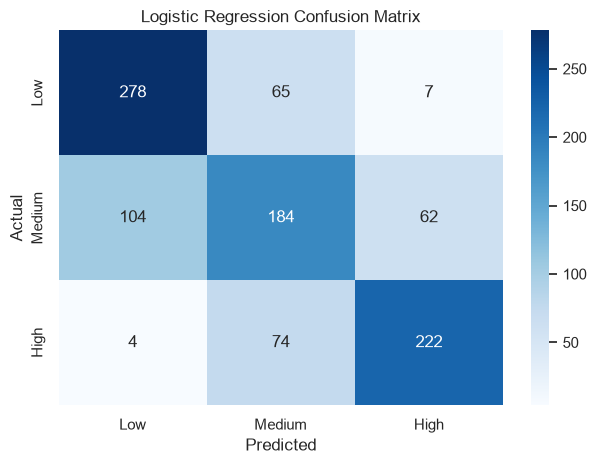

In [75]:
logistic_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])
logistic_pipeline.fit(X_train, y_train)
logistic_predictions = logistic_pipeline.predict(X_test)

logistic_metrics = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, logistic_predictions),
    "Precision": precision_score(y_test, logistic_predictions, average="weighted", zero_division=0),
    "Recall": recall_score(y_test, logistic_predictions, average="weighted", zero_division=0),
    "F1_Score": f1_score(y_test, logistic_predictions, average="weighted", zero_division=0)
}
print(logistic_metrics)
print(classification_report(y_test, logistic_predictions, labels=CLASS_LABELS, zero_division=0))
logistic_cm = confusion_matrix(y_test, logistic_predictions, labels=CLASS_LABELS)
sns.heatmap(logistic_cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS)
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## Model 2 — Random Forest

Train and evaluate a Random Forest pipeline using the same leakage-safe preprocessing.

{'Model': 'Random Forest', 'Accuracy': 0.645, 'Precision': 0.6392699393226282, 'Recall': 0.645, 'F1_Score': 0.6411055645342757}
              precision    recall  f1-score   support

         Low       0.69      0.76      0.72       350
      Medium       0.53      0.47      0.50       350
        High       0.71      0.71      0.71       300

    accuracy                           0.65      1000
   macro avg       0.64      0.65      0.64      1000
weighted avg       0.64      0.65      0.64      1000



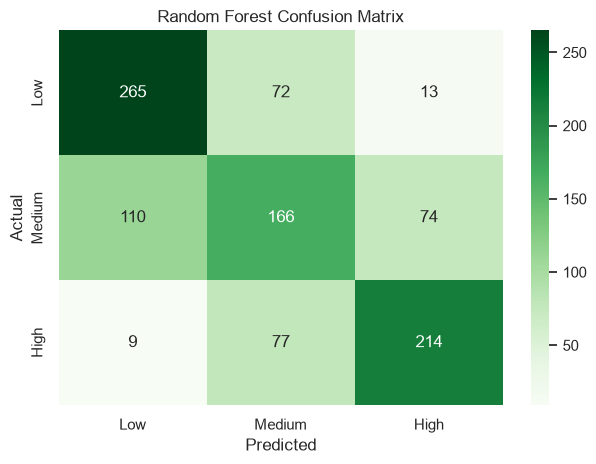

In [76]:
random_forest_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1))
])
random_forest_pipeline.fit(X_train, y_train)
random_forest_predictions = random_forest_pipeline.predict(X_test)

random_forest_metrics = {
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, random_forest_predictions),
    "Precision": precision_score(y_test, random_forest_predictions, average="weighted", zero_division=0),
    "Recall": recall_score(y_test, random_forest_predictions, average="weighted", zero_division=0),
    "F1_Score": f1_score(y_test, random_forest_predictions, average="weighted", zero_division=0)
}
print(random_forest_metrics)
print(classification_report(y_test, random_forest_predictions, labels=CLASS_LABELS, zero_division=0))
random_forest_cm = confusion_matrix(y_test, random_forest_predictions, labels=CLASS_LABELS)
sns.heatmap(random_forest_cm, annot=True, fmt="d", cmap="Greens", xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## Model 3 — XGBoost

Train a three-class XGBoost pipeline with `multi:softprob`, `num_class=3`, and `mlogloss`.

{'Model': 'XGBoost', 'Accuracy': 0.675, 'Precision': 0.6730951887726137, 'Recall': 0.675, 'F1_Score': 0.673802522148633}
              precision    recall  f1-score   support

         Low       0.73      0.77      0.75       350
      Medium       0.56      0.54      0.55       350
        High       0.73      0.72      0.73       300

    accuracy                           0.68      1000
   macro avg       0.68      0.68      0.68      1000
weighted avg       0.67      0.68      0.67      1000



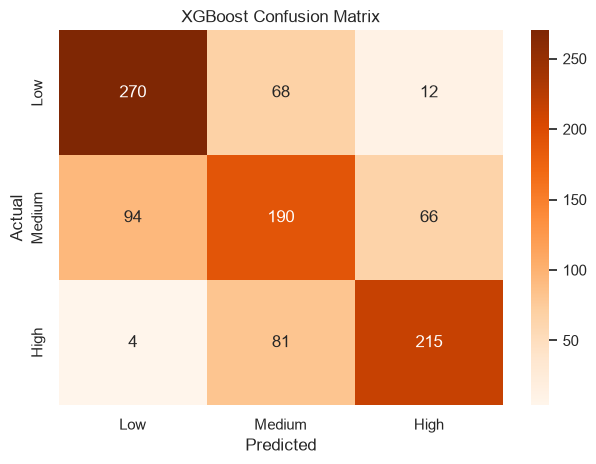

In [77]:
xgb_label_encoder = LabelEncoder()
y_train_encoded = xgb_label_encoder.fit_transform(y_train)
y_test_encoded = xgb_label_encoder.transform(y_test)

xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        n_estimators=200,
        max_depth=5,
        learning_rate=0.08,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method="hist"
    ))
])
xgb_pipeline.fit(X_train, y_train_encoded)
xgb_predictions_encoded = xgb_pipeline.predict(X_test).astype(int)
xgb_predictions = xgb_label_encoder.inverse_transform(xgb_predictions_encoded)

xgb_metrics = {
    "Model": "XGBoost",
    "Accuracy": accuracy_score(y_test, xgb_predictions),
    "Precision": precision_score(y_test, xgb_predictions, average="weighted", zero_division=0),
    "Recall": recall_score(y_test, xgb_predictions, average="weighted", zero_division=0),
    "F1_Score": f1_score(y_test, xgb_predictions, average="weighted", zero_division=0)
}
print(xgb_metrics)
print(classification_report(y_test, xgb_predictions, labels=CLASS_LABELS, zero_division=0))
xgb_cm = confusion_matrix(y_test, xgb_predictions, labels=CLASS_LABELS)
sns.heatmap(xgb_cm, annot=True, fmt="d", cmap="Oranges", xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS)
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## Model Comparison

Compare the actual accuracy, precision, recall, and weighted F1-score for all three models.

,Model,Accuracy,Precision,Recall,F1_Score
0,Logistic Regression,0.684,0.6803,0.684,0.6812
1,Random Forest,0.645,0.6393,0.645,0.6411
2,XGBoost,0.675,0.6731,0.675,0.6738


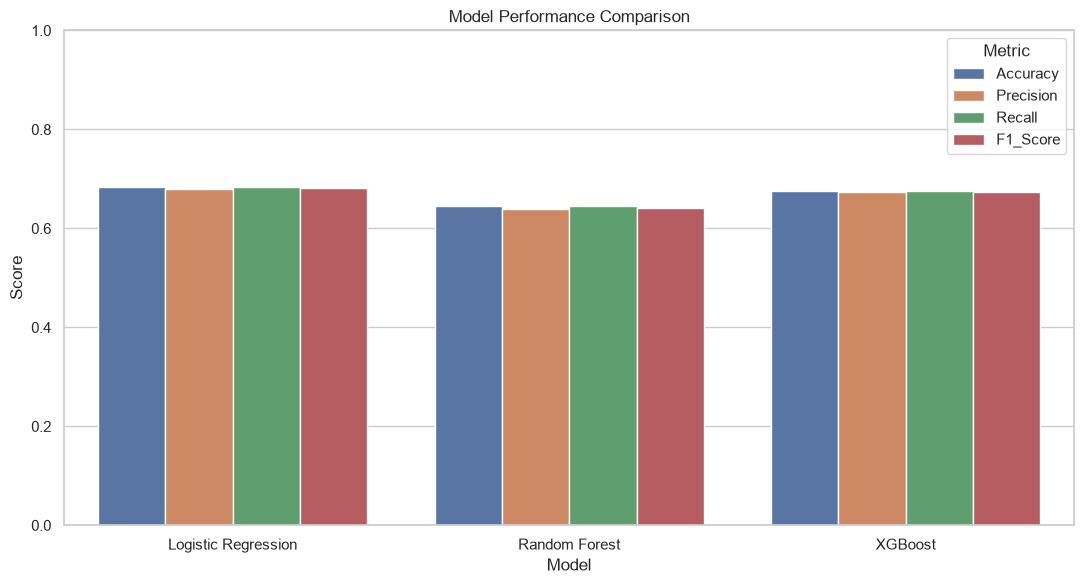

In [78]:
model_comparison = pd.DataFrame([logistic_metrics, random_forest_metrics, xgb_metrics])
model_comparison = model_comparison[["Model", "Accuracy", "Precision", "Recall", "F1_Score"]]
display(model_comparison.round(4))

comparison_long = model_comparison.melt(id_vars="Model", var_name="Metric", value_name="Score")
plt.figure(figsize=(11, 6))
sns.barplot(data=comparison_long, x="Model", y="Score", hue="Metric")
plt.ylim(0, 1)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

## Confusion Matrix Comparison

These matrices show actual classes by rows and predicted classes by columns for the same test set.

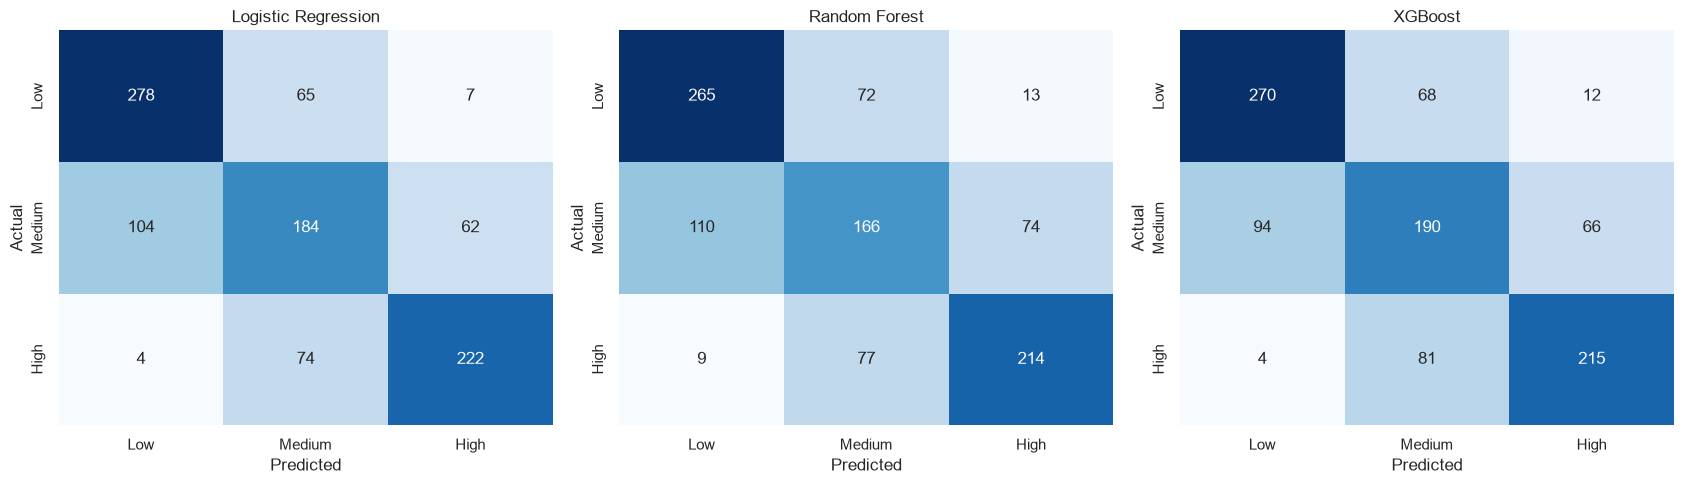

In [79]:
confusion_matrices = {
    "Logistic Regression": logistic_cm,
    "Random Forest": random_forest_cm,
    "XGBoost": xgb_cm
}
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for axis, (model_name, matrix) in zip(axes, confusion_matrices.items()):
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS, ax=axis)
    axis.set_title(model_name)
    axis.set_xlabel("Predicted")
    axis.set_ylabel("Actual")
plt.tight_layout()
plt.show()

## Model Selection

Select a deployment model using the full metric profile rather than accuracy alone.

In [80]:
# Use the mean of all four metrics as a transparent overall score.
model_comparison["Overall_Score"] = model_comparison[["Accuracy", "Precision", "Recall", "F1_Score"]].mean(axis=1)
selected_model_name = model_comparison.sort_values(
    ["Overall_Score", "F1_Score", "Recall", "Precision", "Accuracy"], ascending=False
).iloc[0]["Model"]
model_pipelines = {
    "Logistic Regression": logistic_pipeline,
    "Random Forest": random_forest_pipeline,
    "XGBoost": xgb_pipeline
}
selected_pipeline = model_pipelines[selected_model_name]
selected_metrics = model_comparison.loc[model_comparison["Model"] == selected_model_name].iloc[0]
print("Selected model:", selected_model_name)
for metric in ["Accuracy", "Precision", "Recall", "F1_Score"]:
    print(f"{metric}: {selected_metrics[metric]:.4f}")

Selected model: Logistic Regression
Accuracy: 0.6840
Precision: 0.6803
Recall: 0.6840
F1_Score: 0.6812


## Save Final Model

Save the complete selected pipeline so future raw inputs receive the same imputation, encoding, scaling, and prediction behavior.

In [81]:
from pathlib import Path

models_directory = Path("models")
models_directory.mkdir(exist_ok=True)
model_path = models_directory / "lead_quality_model.pkl"
joblib.dump(selected_pipeline, model_path)
joblib.dump(feature_columns, models_directory / "feature_columns.pkl")
print(f"Saved complete pipeline to: {model_path}")
print(f"Saved feature columns to: {models_directory / 'feature_columns.pkl'}")

Saved complete pipeline to: models\lead_quality_model.pkl
Saved feature columns to: models\feature_columns.pkl


## Sample Lead Prediction

Predict one realistic raw lead and display its class probabilities using the saved pipeline.

In [82]:
sample_lead = pd.DataFrame([{
    "Industry": "Technology",
    "Company_Size": "Large",
    "Website_Quality": "Excellent",
    "LinkedIn_Activity": "High",
    "Email_Available": "Yes",
    "Location": "Lahore",
    "Estimated_Revenue": 2500000,
    "Number_of_Employees": 350,
    "Previous_Response": "Positive",
    "Meeting_Status": "Scheduled"
}])[feature_columns]

saved_pipeline = joblib.load(model_path)
sample_prediction = saved_pipeline.predict(sample_lead)[0]
print("Predicted Lead Quality:", sample_prediction)
if hasattr(saved_pipeline, "predict_proba"):
    sample_probabilities = saved_pipeline.predict_proba(sample_lead)[0]
    probability_table = pd.DataFrame({
        "Lead_Quality": saved_pipeline.classes_,
        "Probability": sample_probabilities
    }).sort_values("Probability", ascending=False)
    display(probability_table.reset_index(drop=True))

Predicted Lead Quality: High


,Lead_Quality,Probability
0,High,0.990542
1,Medium,0.009452
2,Low,0.000006


## Final Project Summary

Summarize the dataset, evaluation workflow, saved artifact, and sample prediction result.

In [83]:
print("AI Lead Quality Prediction - Final Summary")
print("Dataset rows after duplicate removal:", len(df))
print("Number of features:", len(feature_columns))
print("Number of classes:", y.nunique())
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("\nModel comparison:")
display(model_comparison[["Model", "Accuracy", "Precision", "Recall", "F1_Score"]].round(4))
print("\nCompleted: preprocessing, EDA, 3 model trainings, metric evaluation, confusion matrices, final model save, and sample prediction.")

AI Lead Quality Prediction - Final Summary
Dataset rows after duplicate removal: 5000
Number of features: 10
Number of classes: 3
Training samples: 4000
Testing samples: 1000

Model comparison:


,Model,Accuracy,Precision,Recall,F1_Score
0,Logistic Regression,0.684,0.6803,0.684,0.6812
1,Random Forest,0.645,0.6393,0.645,0.6411
2,XGBoost,0.675,0.6731,0.675,0.6738



Completed: preprocessing, EDA, 3 model trainings, metric evaluation, confusion matrices, final model save, and sample prediction.
